# Quantum Fourier Transform: Counter Algorithm
## Phabel Antonio López Delgado <phabel2001@gmail.com>

In [ ]:
# Instalar Librerias
!pip install -q qiskit
!pip install -q qiskit-aer
!pip install -q qiskit[visualization]
!pip install -q pylatexenc

In [ ]:
# Import Libraries
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import CPhaseGate
from qiskit_aer import Aer
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Set number of QBits to count 000 (0) -> 111 (7)
n_qubits = 3

# Function to encode a number into qubits
def encode_number(qc, number):
    for i in range(n_qubits):
        # Encode to binary with bit operation
        if (number >> i) & 1:
            # NOT Gate
            qc.x(i)

# Manual QFT
def manual_qft(qc, qubits):
    n = len(qubits)
    for i in range(n):
        # Hadamard Gate
        qc.h(qubits[i])
        for j in range(i+1, n):
            # Angle as multiple of pi
            angle = np.pi / (2 ** (j - i))
            # New Phase
            qc.append(CPhaseGate(angle), [qubits[j], qubits[i]])
    # Swap qubits to reverse order
    for i in range(n // 2):
        # Swap operation
        qc.swap(qubits[i], qubits[n - i - 1])

# Inverse QFT
def inverse_qft(qc, qubits):
    n = len(qubits)
    # Swap qubits to reverse order
    for i in range(n // 2):
        qc.swap(qubits[i], qubits[n - i - 1])
    # Apply inverse QFT
    for i in reversed(range(n)):
        for j in reversed(range(i+1, n)):
            # Negative Angle as multiple of pi
            angle = -np.pi / (2 ** (j - i))
            # Retrieve Phase
            qc.append(CPhaseGate(angle), [qubits[j], qubits[i]])
        # Hadamard Gate
        qc.h(qubits[i])

# Plot Counts
def plot_counts(counts, number, title_suffix=''):
    plt.figure(figsize=(8, 4))
    states = list(counts.keys())
    counts_vals = list(counts.values())
    plt.bar(states, counts_vals)
    plt.xlabel('Bitstring result')
    plt.ylabel('Counts')
    plt.title(f'Results for input number {number} {title_suffix}')
    plt.show()


Processing number: 0

Results after applying QFT and inverse QFT to number 0:
Counts: {'000': 1024}


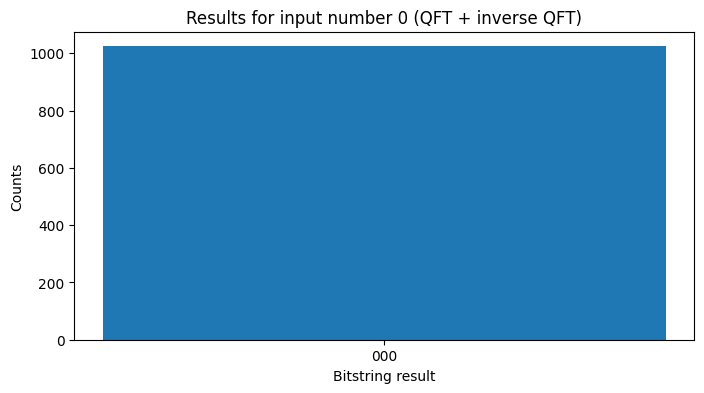


Processing number: 1

Results after applying QFT and inverse QFT to number 1:
Counts: {'001': 1024}


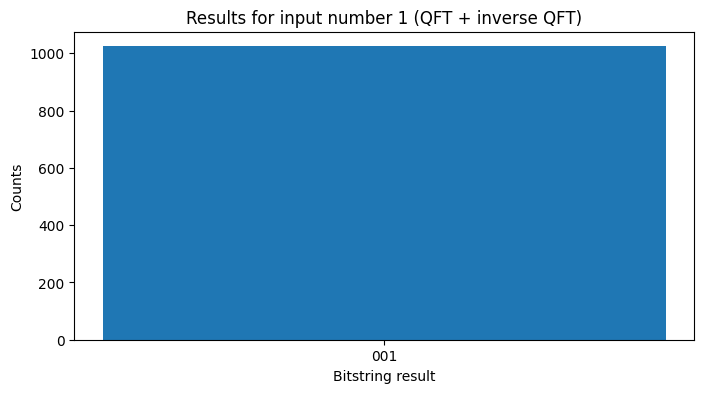


Processing number: 2

Results after applying QFT and inverse QFT to number 2:
Counts: {'010': 1024}


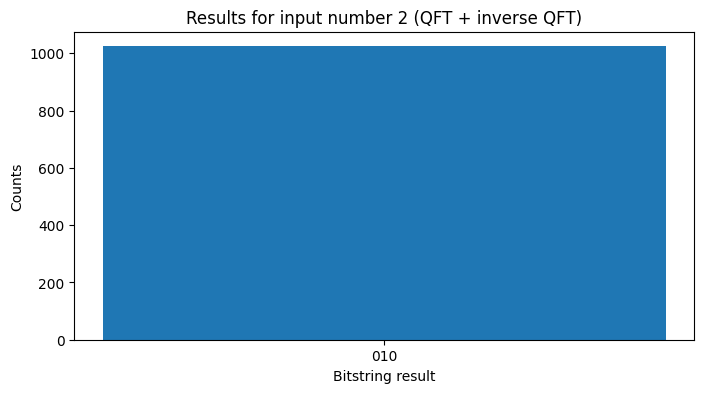


Processing number: 3

Results after applying QFT and inverse QFT to number 3:
Counts: {'011': 1024}


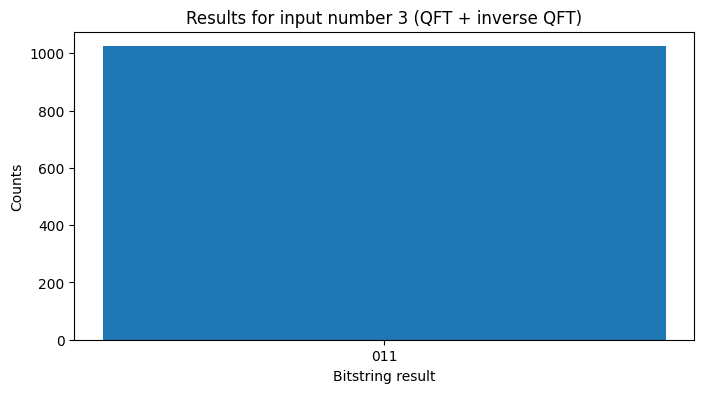


Processing number: 4

Results after applying QFT and inverse QFT to number 4:
Counts: {'100': 1024}


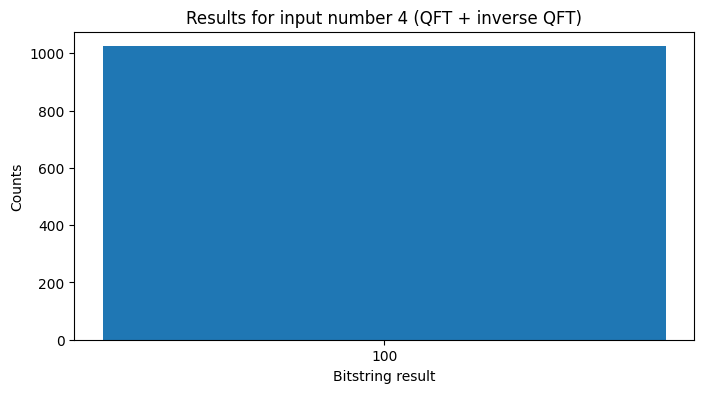


Processing number: 5

Results after applying QFT and inverse QFT to number 5:
Counts: {'101': 1024}


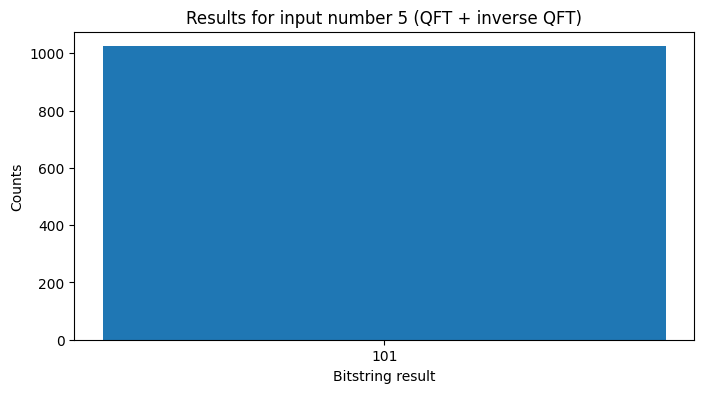


Processing number: 6

Results after applying QFT and inverse QFT to number 6:
Counts: {'110': 1024}


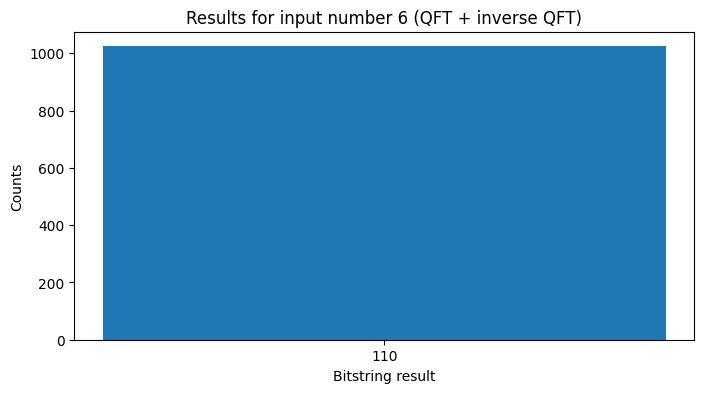


Processing number: 7

Results after applying QFT and inverse QFT to number 7:
Counts: {'111': 1024}


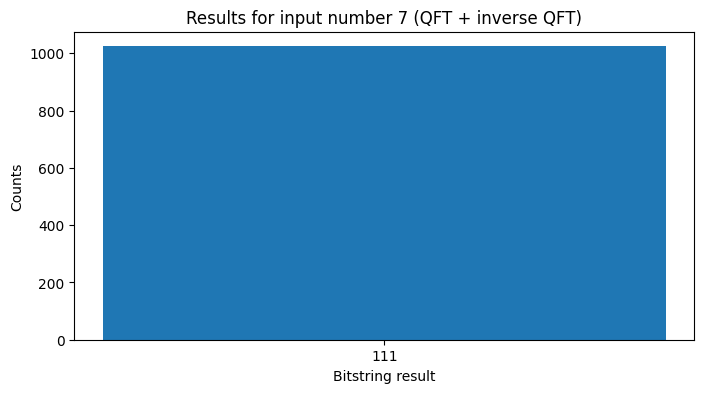

In [ ]:
# Loop over numbers 0 to 7
for number in range(8):
    # Start Counting
    print(f"\nProcessing number: {number}")
    qc = QuantumCircuit(n_qubits, n_qubits)

    # Encode the number
    encode_number(qc, number)

    # Apply manual QFT
    manual_qft(qc, range(n_qubits))

    # Apply inverse QFT
    inverse_qft(qc, range(n_qubits))

    # Measure
    qc.measure(range(n_qubits), range(n_qubits))

    # Run on simulator
    backend = Aer.get_backend('qasm_simulator')
    compile = transpile(qc, backend)
    job = backend.run(compile, shots=1024)

    # Get Job Results
    result = job.result()
    counts = result.get_counts()

    # Print Results
    print(f"\nResults after applying QFT and inverse QFT to number {number}:")
    print(f"Counts: {counts}")

    # Plot
    plot_counts(counts, number, title_suffix='(QFT + inverse QFT)')